Chebyshev Center Project
=====================================================
We will make a function that takes an input a set of points  $\{a_1,a_2,\dots,a_n\}\subseteq\mathbb{R}^n$ and outputs a point $c.$ This point $c$ is called the Chebyshev Center of the set and marks the center of the closed ball of smallest radius that contains each point in our set. 

In [ ]:
# Import Relevant Packages

# magic commands to import modules
# uncomment the following if executing this codeblock returns ModuleNotFoundError
#%pip install --upgrade pip
#%pip install numpy
#%pip install matplotlib
#%pip install cvxpy
#%pip install kagglehub
#%pip install pandas
# Packages
import kagglehub
import numpy as np
import matplotlib.pyplot as plt
import cvxpy as cp
import os

path = kagglehub.dataset_download("sarveshchhetri/student-lifestyle-vs-academic-performance-dataset")

In [ ]:
#print(os.listdir(path))
#csv_path=os.path.join(path, "student_performance_finalscore.csv")
#data = np.genfromtxt(csv_path, delimiter=',', skip_header=1)
#data_relevant=data[:,[3,4,7,8]]

#data_study=data[:,3]
#data_screen=data[:,7]
#data_gpa=data[:,8]
#colors=np.where(data_gpa>3.9, 'red', 'blue')
#print(data_relevant.shape)
#print(data.shape)

In [ ]:
#plt.figure(figsize=(10,10))
#plt.scatter(data_study,data_screen,c=colors)

# Defintions

(Euclidean Norm) For a point $x\in\mathbb{R}^n$ the "length" of the point is given by $$\|x\|_2=
    (\sum_{i=1}^{n} x_i^2)^{\frac{1}{2}} \text{ for } i=1,2,\dots, n$$

(Closed Ball) A closed ball of radius $r$ in $\mathbb{R}^n$ about a point $c$ is a set containing every point at most a distance of $r$ away from $c$. Symbolically,

$$\text{B}[c,r]=\{x\in\mathbb{R}^n~:~\|x-c\|_2\leq r\}$$



# Motivation

Our goal is to minimize $r$ given the contraint(s),
    $$\|c-a_i\|\leq r$$
Hence, we can approach this problem as a convex optimization problem and will make use of the CVXPY Python Package, that is, we have the following convex problem. Let $c$ denote our Chebyshev center, and $a_i$ be a point in the set of which we are trying to find the center.
    $$
        \begin{align*}
            &\underset{c,r}{\text{min}}&&r\\
            &\text{s.t.} &&\|c-a_i\|\leq r \text{ for all } i=1,2,\dots
        \end{align*}
    $$

In [ ]:
# Define Function
def chebyshev_center(points):
    #This function will take in a list of points in R^n and output a point c
    #representing the center of the ball of minimal radius containing every 
    #vector in our list
    points=np.array(points)
    r=cp.Variable()
    c=cp.Variable(len(points[0])) #This makes our point c exist in the same space
                                  #as points in our list
    objective = cp.Minimize(r)
    
    #Make our set of contraints
    constraints=[]
    for i in range(len(points)):
        ai = points[i]
        constraints.append(cp.norm(c-ai,2)<=r)
    
    #solve
    problem=cp.Problem(objective,constraints)
    chebyshev_radius=problem.solve()

    print(f'The ball of radius r={chebyshev_radius:.2f} centered at the Chebyshev Center c={np.round(c.value,5)} contains each point in the set.')

    if len(points[0])==2:
        print('\n Your data set contains 2-D points; lets graph it!')

        plt.figure(figsize=(6,6))
        #points of argument
        plt.scatter(points[:,0],points[:,1],s=25,c="red",marker='o',label='Dataset')
        
        #chebyshev center
        plt.scatter(c.value[0],c.value[1],s=100,c='blue',marker='*',label='Chebyshev Center')

        #chebyshev circle
        theta=np.linspace(0,2*np.pi,100)
        plt.plot(r.value*np.cos(theta)+c.value[0],r.value*np.sin(theta)+c.value[1],color='blue')

        plt.legend()
        plt.title('Chebyshev Center')
        plt.show()

# Examples

### Example 1: Circle
We would hope that given a set of points on a circle, our function finds the origin:

The ball of radius r=3.00 centered at the Chebyshev Center c=[-0. -0.] contains each point in the set.

 Your data set contains 2-D points; lets graph it!


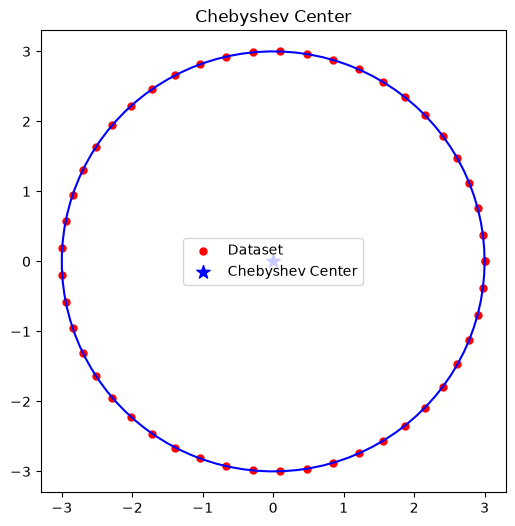

In [ ]:
theta1=np.linspace(0,2*np.pi,50)
test1=[]
for t in theta1:
    test1.append([3*np.cos(t), 3*np.sin(t)])
                 
chebyshev_center(test1)

### Example 2: A set of random points in $\mathbb{R}^2$

The ball of radius r=2.75 centered at the Chebyshev Center c=[-0.0018  0.2653] contains each point in the set.

 Your data set contains 2-D points; lets graph it!


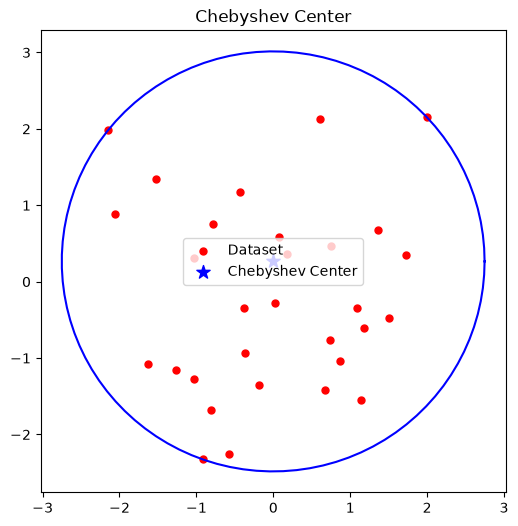

In [ ]:
chebyshev_center(np.random.randn(30,2))

### Example 3: Real World Application
Suppose we wanted to open a student hub, a business whose primary customer would be students, and we wanted optimize its location such that the furthest students would have the shortest trip to the store. By doing this, students nearby should have a negligible increase in their commute time, but those furthest away would have a much shorter trip. 

I collected the longitude and latitude values for various colleges, trade schools, and universities in Colorado Springs and entered each pair as an element in a numpy array of which our function can find the Chebyshev Center. Plotted below are these schools as well as the optimal location to place a student-facing business. 

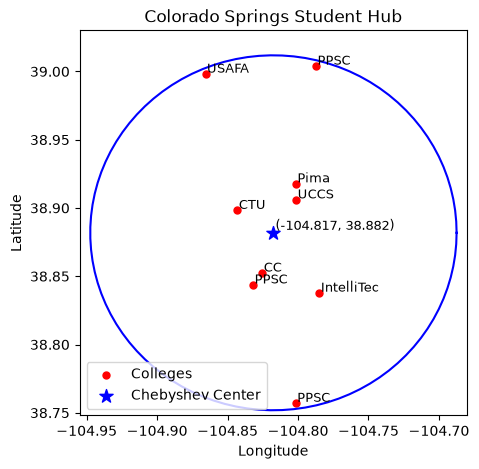

In [ ]:
##Data Set
Unis=np.array([[38.75700294655235, -104.801575106403760],
               [38.843693386210326, -104.83178750854992],
               [39.003952612361225, -104.78715555083402],
               [38.90597037715892, -104.8012317836521],
               [38.85238336581321, -104.82526437626838],
               [38.998082836931204, -104.86560479985248],
               [38.917775005872144, -104.80142459903077],
               [38.83768694576428, -104.78477365472195],
               [38.89827107694304, -104.8429628792255]
                ])                                       
# Points above are are given as (latitude,longitude); reverse the order

## Points and Labels
Unis2=[]  #Coordintes of universities but in (long,lat)
for loc in Unis:
    Unis2.append([loc[1],loc[0]])

schools=["PPSC","PPSC","PPSC","UCCS","CC","USAFA","Pima","IntelliTec","CTU"]

#chebyshev_center(Unis2)


##After this line is used to graph plots. (un)comment as neccesary to show (add)remove plot features

plt.figure(figsize=(5,5))
#points of argument
plt.scatter(np.array(Unis2)[:,0],np.array(Unis2)[:,1],s=25,c="red",marker='o',label='Colleges')
for i, school in enumerate(schools):
    plt.text(np.array(Unis2)[i,0] + 0.001, np.array(Unis2)[i,1] + 0.001, school, fontsize=9)


##Illustrative Purpose((Un)comment as needed)
#badS=np.array([-104.825,38.93])  #nonideal point to illustrate intuitive ideas
#plt.scatter(badS[0],badS[1], s=100, marker='*',color='blue',label='Student Hub')

#plt.plot([-104.825,-104.801575106403760],[38.93,38.75700294655235],'g--') #line to illustrate "fairness"
#plt.plot([-104.825,-104.80142459903077], [38.93,38.917775005872144],'g--')


#plt.scatter(-104.80, 38.875,marker='$?$',s=300, color='black',label='Student Hub') #point to illustrate intuitive ideas



## Chebyshev components (un)comment to (add)remove the center and circle from the graph

#chebyshev center (uncomment if plot wants the center graphed) (x,y) from chebyshev_center(Unis2)
plt.scatter(-104.81746,38.88183,s=100,c='blue',marker='*',label='Chebyshev Center')
plt.text(-104.817 + 0.001, 38.882 + 0.002, (-104.817,38.882) ,fontsize=9)

#chebyshev circle
theta=np.linspace(0,2*np.pi,100)
plt.plot(.13*np.cos(theta)+-104.81746,.13*np.sin(theta)+38.88183,color='blue')


##Visuals
plt.xlim(-104.955, -104.68)
plt.ylim(38.748, 39.03)
plt.legend(loc='lower left')
plt.title('Colorado Springs Student Hub')
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()